<a href="https://colab.research.google.com/github/JunUehara56/CP5_SERS/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## Importação das bibliotecas

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Carregamento do dataset

In [8]:
# Carregando o dataset a partir do link correto fornecido
url = "https://raw.githubusercontent.com/JunUehara56/CP5_SERS/refs/heads/main/aneel_classificacao_orange.csv"
df = pd.read_csv(url)

# Visualizando as primeiras linhas
df.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


## Análise inicial do dataset

In [9]:
# Verificando as dimensões do DataFrame (linhas e colunas)
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 3876
Quantidade de colunas: 4


In [10]:
# Apresentando os nomes e os tipos das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [11]:
# Verificando se existem valores ausentes
valores_ausentes = df.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes[valores_ausentes > 0] if (valores_ausentes > 0).any() else "Nenhum valor ausente encontrado.")

Valores ausentes por coluna:
Nenhum valor ausente encontrado.


In [12]:
# Apresentando as estatísticas descritivas das variáveis numéricas
df.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [13]:
# Estatísticas de colunas categóricas
df.describe(include='object')

,fonte
count,3876
unique,3
top,Hidráulica
freq,1476


## Análise da variável alvo 'fonte'

In [14]:
# Lista das categorias da coluna alvo
df['fonte'].unique()

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [15]:
# Contagem das categorias da coluna 'fonte'
df['fonte'].value_counts()

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


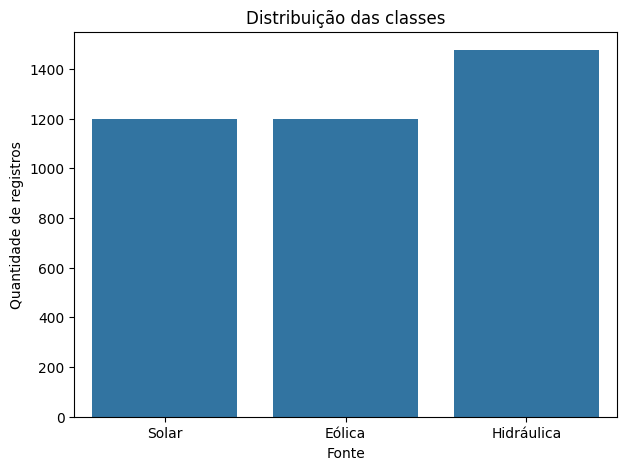

In [58]:
# Gráfico comparativo da distribuição das classes da coluna alvo
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='fonte')
plt.title('Distribuição das classes')
plt.xlabel('Fonte')
plt.ylabel('Quantidade de registros')
plt.show()

### **Definição das variáveis:**

`X` representa as variáveis de entrada utilizadas pelos modelos: `potencia_kw`, `latitude` e `longitude`. A variável y representa o alvo da classificação, definido pela coluna `fonte`, que possui as classes Solar, Eólica e Hidráulica.

In [25]:
# Variáveis de entrada (features)
X = df[['potencia_kw', 'latitude', 'longitude']]

# Variável de saída (target)
y = df['fonte']

display(X.head())
display(y.head())

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


## Separação entre treino e teste

In [42]:
# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")

Treino: 3100 registros
Teste: 776 registros


In [35]:
# Ajuste de escala dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Justificativa da escolha dos classificadores**

A **Regressão Logística** foi utilizada como um modelo linear de referência para verificar se as classes podem ser separadas a partir de relações mais simples entre as variáveis. O **Gaussian Naive Bayes** foi escolhido por ser um método probabilístico adequado para variáveis numéricas contínuas. Por fim, a **Decision Tree** foi utilizada por conseguir representar relações não lineares e criar diferentes regras de decisão a partir das características dos dados. Dessa forma, é possível comparar abordagens distintas utilizando a mesma divisão de treino e teste.

# Modelo 1 (Regressão Logística)

## Treinamento e previsões do Modelo 1

In [40]:
# Criação e treinamento do modelo Logistic Regression
modelo1 = LogisticRegression(max_iter=1000, random_state=42)
modelo1.fit(X_train_scaled, y_train)

# Geração das previsões para o Modelo 1
y_pred1 = modelo1.predict(X_test_scaled)

## Métricas do Modelo 1


In [46]:
# Métricas do Modelo 1
accuracy1 = accuracy_score(y_test, y_pred1)
precision1 = precision_score(y_test, y_pred1, average='macro')
recall1 = recall_score(y_test, y_pred1, average='macro')
f1_1 = f1_score(y_test, y_pred1, average='macro')

print(f"Acurácia: {accuracy1:.4f}")
print(f"Precisão: {precision1:.4f}")
print(f"Recall: {recall1:.4f}")
print(f"F1-Score: {f1_1:.4f}")

Acurácia: 0.8247
Precisão: 0.8282
Recall: 0.8214
F1-Score: 0.8197


## Matriz de Confusão

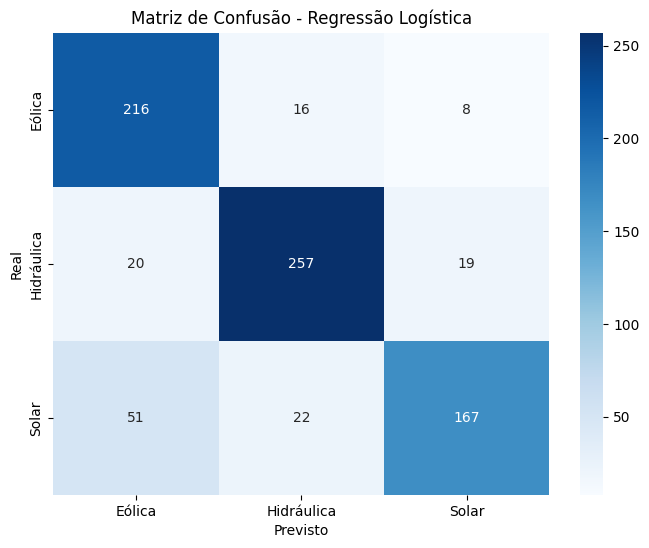

In [43]:
# Matriz de confusão do Modelo 1
matriz1 = confusion_matrix(y_test, y_pred1)

# Visualização da matriz
plt.figure(figsize=(8, 6))
sns.heatmap(matriz1, annot=True, fmt='d', cmap='Blues', xticklabels=modelo1.classes_, yticklabels=modelo1.classes_)
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### **Interpretação do Modelo 1:**

A **Regressão Logística** apresentou acurácia de 82,47%, precisão macro de 82,82%, recall macro de 82,14% e F1-score macro de 81,97%. Pela matriz de confusão, o modelo teve maior dificuldade na classificação da fonte Solar, confundindo 51 registros solares com a classe Eólica. A classe Eólica apresentou 216 classificações corretas, a Hidráulica 257 e a Solar 167. Esses resultados indicam que as variáveis potência, latitude e longitude conseguem diferenciar boa parte das fontes, mas ainda ocorrem confusões entre algumas classes, principalmente entre Solar e Eólica.

# Modelo 2 (Gaussian Naive Bayes)

## Treinamento e previsões do Modelo 2

In [47]:
# Criação e treinamento do modelo GaussianNB
modelo2 = GaussianNB()
modelo2.fit(X_train_scaled, y_train)

# Geração das previsões para o Modelo 2
y_pred2 = modelo2.predict(X_test_scaled)

## Métricas do Modelo 2


In [48]:
# Métricas do Modelo 2
accuracy2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2, average='macro')
recall2 = recall_score(y_test, y_pred2, average='macro')
f1_2 = f1_score(y_test, y_pred2, average='macro')

print(f"Acurácia: {accuracy2:.4f}")
print(f"Precisão: {precision2:.4f}")
print(f"Recall: {recall2:.4f}")
print(f"F1-Score: {f1_2:.4f}")

Acurácia: 0.7023
Precisão: 0.7332
Recall: 0.7152
F1-Score: 0.6994


## Matriz de Confusão

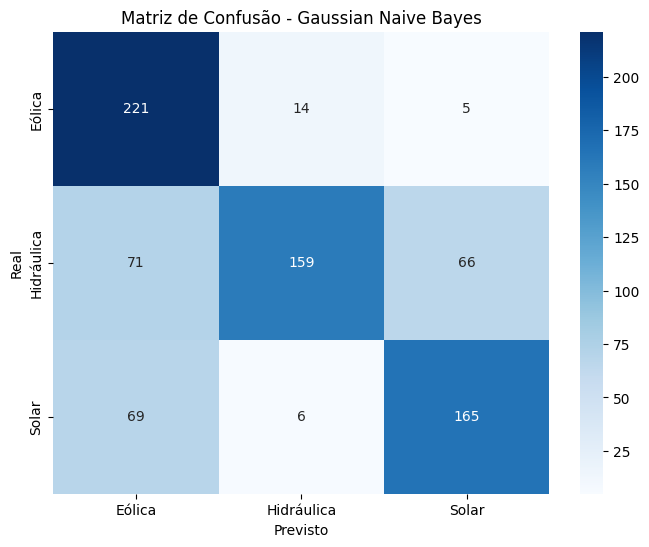

In [49]:
# Matriz de confusão do Modelo 2
matriz2 = confusion_matrix(y_test, y_pred2)

# Visualização da matriz
plt.figure(figsize=(8, 6))
sns.heatmap(matriz2, annot=True, fmt='d', cmap='Blues', xticklabels=modelo2.classes_, yticklabels=modelo2.classes_)
plt.title('Matriz de Confusão - Gaussian Naive Bayes')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### **Interpretação do Modelo 2:**

O modelo **Gaussian Naive** Bayes apresentou acurácia de 70,23%, com precisão macro de 73,32%, recall macro de 71,52% e F1-score macro de 69,94%. Pela matriz de confusão, a classe Eólica foi a que apresentou mais acertos, com 221 classificações corretas. O modelo apresentou maior dificuldade com a classe Hidráulica, acertando 159 casos e confundindo principalmente com Eólica (71 casos) e Solar (66 casos). Também houve uma quantidade relevante de fontes Solares classificadas como Eólicas (69 casos). Esses resultados mostram que o modelo possui dificuldade em separar algumas das classes utilizando apenas potência, latitude e longitude.

# Modelo 3 (Decision Tree)

## Treinamento e previsões do Modelo 3

In [52]:
# Criação e treinamento do modelo Decision Tree
modelo3 = DecisionTreeClassifier(random_state=42)
modelo3.fit(X_train_scaled, y_train)

# Geração das previsões para o Modelo 3
y_pred3 = modelo3.predict(X_test_scaled)

## Métricas do Modelo 3

In [51]:
# Métricas do Modelo 3
accuracy3 = accuracy_score(y_test, y_pred3)
precision3 = precision_score(y_test, y_pred3, average='macro')
recall3 = recall_score(y_test, y_pred3, average='macro')
f1_3 = f1_score(y_test, y_pred3, average='macro')

print(f"Acurácia: {accuracy3:.4f}")
print(f"Precisão: {precision3:.4f}")
print(f"Recall: {recall3:.4f}")
print(f"F1-Score: {f1_3:.4f}")

Acurácia: 0.9613
Precisão: 0.9614
Recall: 0.9610
F1-Score: 0.9612


## Matriz de Confusão

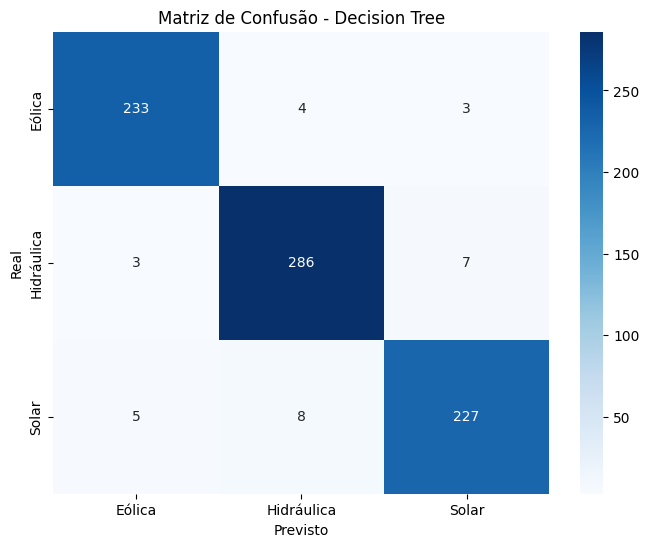

In [54]:
# Matriz de confusão do Modelo 3
matriz3 = confusion_matrix(y_test, y_pred3)

# Visualização da matriz
plt.figure(figsize=(8, 6))
sns.heatmap(matriz3, annot=True, fmt='d', cmap='Blues', xticklabels=modelo3.classes_, yticklabels=modelo3.classes_)
plt.title('Matriz de Confusão - Decision Tree')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### **Interpretação do Modelo 3:**

A **Decision Tree** apresentou acurácia de 96,13%, precisão macro de 96,14%, recall macro de 96,10% e F1-score macro de 96,12%. A matriz de confusão mostra um alto número de classificações corretas nas três classes: 233 Eólicas, 286 Hidráulicas e 227 Solares. Os erros foram baixos, sendo a maior confusão entre Solar e Hidráulica, com 8 registros solares classificados como hidráulicos. Dessa forma, o modelo conseguiu distinguir muito bem as três fontes utilizando as variáveis potência, latitude e longitude.

# Tabela comparativa dos três modelos

In [55]:
# Tabela comparativa dos três modelos
comparacao = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Gaussian Naive Bayes', 'Decision Tree'],
    'Acurácia': [accuracy1, accuracy2, accuracy3],
    'Precisão (macro)': [precision1, precision2, precision3],
    'Recall (macro)': [recall1, recall2, recall3],
    'F1-Score (macro)': [f1_1, f1_2, f1_3]
})

comparacao

,Modelo,Acurácia,Precisão (macro),Recall (macro),F1-Score (macro)
0,Regressão Logística,0.824742,0.828208,0.821359,0.819677
1,Gaussian Naive Bayes,0.702320,0.733203,0.715165,0.699397
2,Decision Tree,0.961340,0.961447,0.960961,0.961187


**Comparação dos modelos:**

Os três classificadores foram treinados e avaliados utilizando a mesma divisão estratificada de treino e teste. Para Precision, Recall e F1-score foi utilizada a média macro, que calcula a métrica individualmente para cada classe e atribui o mesmo peso às três fontes.

Nos resultados obtidos, a **Decision Tree** apresentou as maiores métricas, com acurácia de 96,13%, precisão macro de 96,14%, recall macro de 96,10% e F1-score macro de 96,12%. A **Regressão Logística** apresentou resultados intermediários, com acurácia de 82,47%, enquanto o **Gaussian Naive Bayes** apresentou acurácia de 70,23%.

### **Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real.**

Considerando estes resultados no conjunto de teste, a **Decision Tree** seria o modelo escolhido, pois apresentou o melhor desempenho entre os três classificadores avaliados. Sua matriz de confusão também apresentou poucos erros nas três classes, com 233 classificações corretas para Eólica, 286 para Hidráulica e 227 para Solar.

Apesar do bom desempenho obtido, utilizar somente `potencia_kw`, `latitude` e `longitude` pode não ser suficiente em uma aplicação real. Diferentes tipos de fontes podem apresentar potências semelhantes e também podem estar localizados em regiões próximas. Além disso, essas três variáveis não representam todas as características que distinguem uma fonte de geração. Isso pode explicar parte das confusões observadas entre Solar, Eólica e Hidráulica. Portanto, o desempenho obtido neste conjunto de dados não garante que o modelo apresentaria o mesmo resultado com novos dados de outras regiões ou contextos.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [21]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [22]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [23]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [24]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## Importação das bibliotecas


In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Carregamento do dataset



In [65]:
# Carregando o dataset a partir do link correto fornecido
url = "https://raw.githubusercontent.com/JunUehara56/CP5_SERS/refs/heads/main/meteo_regressao_orange.csv"
df = pd.read_csv(url)

# Visualizando as primeiras linhas
df.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


## Análise inicial do dataset

In [66]:
# Verificando as dimensões do DataFrame (linhas e colunas)
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 1001
Quantidade de colunas: 7


In [67]:
# Apresentando os nomes e os tipos das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


In [68]:
# Verificando se existem valores ausentes
valores_ausentes = df.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes[valores_ausentes > 0] if (valores_ausentes > 0).any() else "Nenhum valor ausente encontrado.")

Valores ausentes por coluna:
Nenhum valor ausente encontrado.


In [69]:
# Apresentando as estatísticas descritivas das variáveis numéricas
df.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


## Definição da variáveis X e y

In [78]:
# Garantir a ordem temporal dos registros
df['data_hora'] = pd.to_datetime(df['data_hora'])
df = df.sort_values('data_hora').reset_index(drop=True)

In [79]:
# Definição das variáveis de entrada (X) e variável alvo (y)
X = df[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y = df['radiacao_w_m2']

display(X.head())
display(y.head())

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11


,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0


## Matriz de Correlação

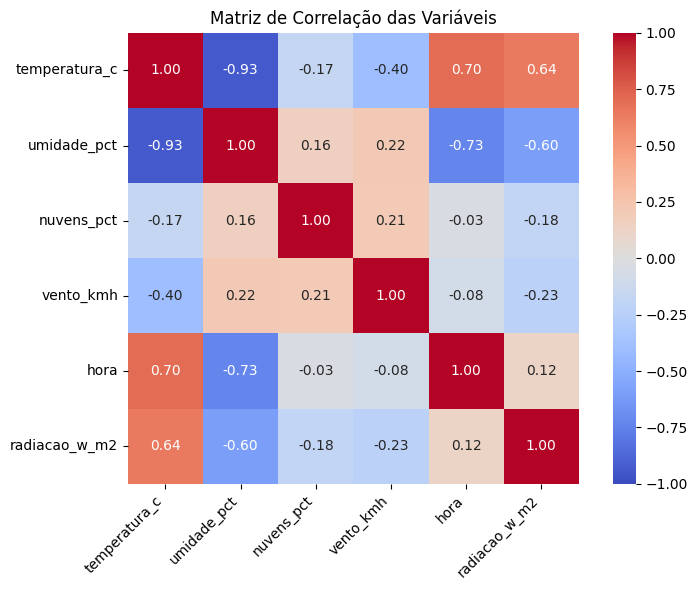

In [87]:
# Matriz de correlação das variáveis
colunas = ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora', 'radiacao_w_m2']
plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas].corr(),annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.title('Matriz de Correlação das Variáveis')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Separação entre treino e teste

In [80]:
# Separação temporal entre treino (80%) e teste (20%)
corte = int(len(df) * 0.80)

X_treino = X.iloc[:corte]
X_teste = X.iloc[corte:]

y_treino = y.iloc[:corte]
y_teste = y.iloc[corte:]

print(f"Treino: {X_treino.shape[0]} registros")
print(f"Teste: {X_teste.shape[0]} registros")

Treino: 800 registros
Teste: 201 registros


### **Justificativa da escolha dos classificadores**

A **Regressão Linear** foi escolhida como modelo de referência por representar relações lineares entre as variáveis de entrada e a radiação solar. A **Decision Tree Regressor** foi escolhida por ser capaz de representar relações não lineares por meio de divisões sucessivas dos dados. Por fim, o **Random Forest Regressor** foi escolhido por combinar várias árvores de decisão, buscando produzir previsões mais estáveis e reduzir a dependência de uma única árvore.
Os três modelos foram treinados utilizando a mesma divisão temporal de treino e teste, permitindo uma comparação consistente entre seus resultados.

# Modelo 1 (Regressão Linear)

## Treinamento e previsões do Modelo 1

In [83]:
# Criação e treinamento do modelo Linear Regression
modelo1_reg = LinearRegression()
modelo1_reg.fit(X_treino, y_treino)

# Geração das previsões para o Modelo 1
y_pred1_reg = modelo1_reg.predict(X_teste)

## Métricas do Modelo 1


In [85]:
# Métricas do Modelo 1
mae1 = mean_absolute_error(y_teste, y_pred1_reg)
mse1 = mean_squared_error(y_teste, y_pred1_reg)
r2_1 = r2_score(y_teste, y_pred1_reg)

print(f"MAE: {mae1:.2f} W/m²")
print(f"MSE: {mse1:.2f} (W/m²)²")
print(f"R²: {r2_1:.4f}")

MAE: 145.20 W/m²
MSE: 30034.20 (W/m²)²
R²: 0.3598


### **Interpretação do Modelo 1:**
A **Regressão Linear** apresentou MAE de 145,20 W/m², indicando que as previsões se afastam dos valores reais em aproximadamente 145,20 W/m², em média. O MSE foi de 30.034,20 (W/m²)², métrica que penaliza de forma mais intensa os erros de maior magnitude. O R² obtido foi de 0,3598, indicando que o modelo explica aproximadamente 35,98% da variação da radiação solar no conjunto de teste. Esses resultados mostram que a Regressão Linear consegue capturar parte do comportamento da radiação, mas ainda apresenta limitações na representação das relações existentes entre as variáveis de entrada e o valor previsto.

## Modelo 2 (Decision Tree Regressor)

## Treinamento e previsões do Modelo 2

In [91]:
# Criação e treinamento do modelo Decision Tree Regressor
modelo2_reg = DecisionTreeRegressor(random_state=42)
modelo2_reg.fit(X_treino, y_treino)

# Geração das previsões para o Modelo 2
y_pred2_reg = modelo2_reg.predict(X_teste)

## Métricas do Modelo 2

In [92]:
# Métricas do Modelo 2
mae2 = mean_absolute_error(y_teste, y_pred2_reg)
mse2 = mean_squared_error(y_teste, y_pred2_reg)
r2_2 = r2_score(y_teste, y_pred2_reg)

print(f"MAE: {mae2:.2f} W/m²")
print(f"MSE: {mse2:.2f} (W/m²)²")
print(f"R²: {r2_2:.4f}")

MAE: 88.79 W/m²
MSE: 15291.16 (W/m²)²
R²: 0.6741


### **Interpretação do Modelo 2:**

A **Decision Tree Regressor** apresentou MAE de 88,79 W/m², MSE de 15.291,16 (W/m²)² e R² de 0,6741. Em comparação com a Regressão Linear, houve redução dos erros e aumento do R², indicando que a Árvore de Decisão conseguiu representar melhor as relações entre as variáveis de entrada e a radiação solar. O modelo explica aproximadamente 67,41% da variação da radiação no conjunto de teste.

## Modelo 3 (Random Forest)

## Treinamento e previsões do Modelo 3

In [93]:
# Criação e treinamento do modelo Random Forest Regressor
modelo3_reg = RandomForestRegressor(random_state=42)
modelo3_reg.fit(X_treino, y_treino)

# Geração das previsões para o Modelo 3
y_pred3_reg = modelo3_reg.predict(X_teste)

## Métricas do Modelo 3

In [94]:
# Métricas do Modelo 3
mae3 = mean_absolute_error(y_teste, y_pred3_reg)
mse3 = mean_squared_error(y_teste, y_pred3_reg)
r2_3 = r2_score(y_teste, y_pred3_reg)

print(f"MAE: {mae3:.2f} W/m²")
print(f"MSE: {mse3:.2f} (W/m²)²")
print(f"R²: {r2_3:.4f}")

MAE: 66.80 W/m²
MSE: 7307.42 (W/m²)²
R²: 0.8442


### **Interpretação do Modelo 3:**

O **Random Forest Regressor** apresentou MAE de 66,80 W/m², MSE de 7.307,42 (W/m²)² e R² de 0,8442. O MAE indica que as previsões se afastam dos valores reais em aproximadamente 66,80 W/m², em média. O R² mostra que o modelo explica aproximadamente 84,42% da variação da radiação solar no conjunto de teste. Em comparação com a Regressão Linear e a Decision Tree, o Random Forest apresentou menores valores de MAE e MSE e maior R², indicando um melhor desempenho entre os três modelos avaliados.

# Tabela comparativa dos três modelos

In [97]:
# Tabela comparativa dos três modelos
comparacao_reg = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Decision Tree', 'Random Forest'],
    'MAE (W/m²)': [mae1, mae2, mae3],
    'MSE ((W/m²)²)': [mse1, mse2, mse3],
    'R²': [r2_1, r2_2, r2_3]
})

comparacao_reg

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.204885,30034.201092,0.359845
1,Decision Tree,88.791045,15291.159204,0.674081
2,Random Forest,66.804179,7307.417901,0.844248


**Comparação dos modelos:**

Os três modelos de regressão foram treinados e avaliados utilizando a mesma divisão temporal dos dados, com aproximadamente 80% das primeiras horas destinadas ao treinamento e as 20% finais ao teste, preservando a ordem cronológica dos registros. Para a comparação foram utilizadas as métricas MAE, MSE e R². No MAE e no MSE, valores menores indicam erros menores, enquanto no R² valores maiores indicam maior capacidade do modelo de explicar a variação da variável alvo.

Nos resultados obtidos, a **Regressão Linear** apresentou MAE de 145,20 W/m², MSE de 30.034,20 (W/m²)² e R² de 0,3598, sendo o modelo com os maiores erros entre os três avaliados. A **Decision Tree** apresentou uma melhora, reduzindo o MAE para 88,79 W/m² e o MSE para 15.291,16 (W/m²)², além de alcançar R² de 0,6741.

O **Random Forest** apresentou os menores erros e o maior R², com MAE de 66,80 W/m², MSE de 7.307,42 (W/m²)² e R² de 0,8442. Isso representa uma redução considerável dos erros em relação aos outros modelos e indica que o **Random Forest** conseguiu explicar aproximadamente 84,42% da variação da radiação solar no conjunto de teste.

Considerando os resultados obtidos no conjunto de teste, o **Random Forest** seria o modelo escolhido entre os três avaliados, pois apresentou simultaneamente o menor MAE, o menor MSE e o maior R². Os resultados também sugerem que relações não lineares entre temperatura, umidade, cobertura de nuvens, velocidade do vento, hora do dia e radiação solar são relevantes para o problema, já que os modelos baseados em árvores apresentaram resultados superiores aos da Regressão Linear.

# Gráfico de valores reais × previstos do Modelo 3 (Random Forest)

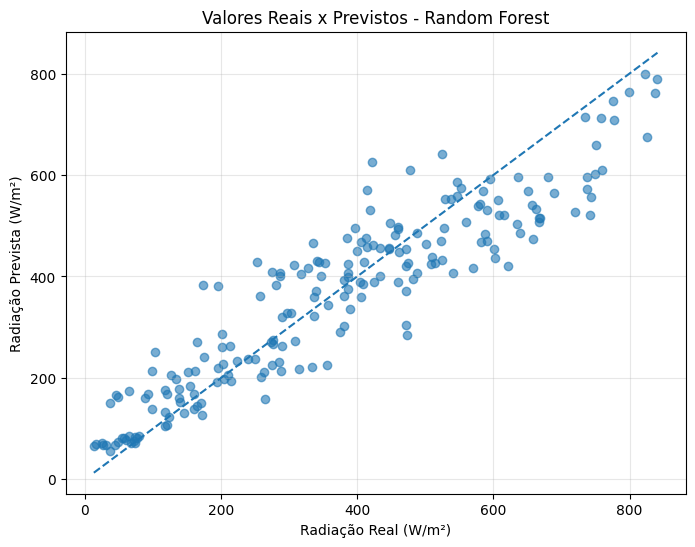

In [96]:
# Gráfico de Valores reais x previstos - Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(y_teste, y_pred3_reg, alpha=0.6)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], '--')
plt.xlabel('Radiação Real (W/m²)')
plt.ylabel('Radiação Prevista (W/m²)')
plt.title('Valores Reais x Previstos - Random Forest')
plt.grid(alpha=0.3)
plt.show()

### Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

Os resultados mostram que ainda existem diferenças entre os valores reais e previstos de radiação solar, mesmo no Random Forest, que apresentou o melhor desempenho entre os três modelos. Seu MAE de 66,80 W/m² indica que, em média, as previsões apresentam um erro absoluto de aproximadamente 66,80 W/m². O gráfico de valores reais × previstos também mostra que grande parte das previsões acompanha os valores reais, embora ainda existam desvios, principalmente em alguns valores mais elevados de radiação.

A variável `hora` possui um papel importante, pois a radiação solar varia ao longo do dia. Durante a manhã, a radiação tende a aumentar conforme o Sol se eleva, atingindo valores maiores próximo ao período central do dia e diminuindo posteriormente. Dessa forma, a relação entre hora e radiação não é necessariamente linear, o que ajuda a explicar por que a correlação linear entre `hora` e `radiacao_w_m2` pode ser baixa mesmo que a hora seja relevante para a previsão.

Por fim, estimar a radiação solar em W/m² **não equivale automaticamente a prever a energia elétrica produzida por um sistema fotovoltaico**. A radiação representa a energia solar incidente por unidade de área, enquanto a geração elétrica também depende de características do sistema, como área e eficiência dos módulos, orientação e inclinação dos painéis, temperatura de operação e perdas do sistema. Como essas informações não fazem parte das entradas utilizadas neste modelo, a previsão realizada corresponde à radiação solar e não diretamente à geração de energia elétrica.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)